In [1]:
import random
from tqdm import tqdm
from collections import defaultdict
def get_available_nodes(graph, source, hop=1):
    if hop == 0:
        return set(graph.keys()) - {source}
    current = {source}
    visited = {source}
    available_nodes = set()
    for _ in range(hop):
        next_level = set()
        for node in current:
            neighbors = graph[node]
            available_nodes.update(neighbors)
            for neighbor in neighbors:
                if neighbor not in visited:
                    visited.add(neighbor)
                    next_level.add(neighbor)
        current = next_level
        if not current:
            break
    available_nodes.discard(source)
    return available_nodes

def simulate(graph, victim, originator, available_nodes, p=1):
    if originator not in available_nodes:
        raise ValueError("Originator not in victim neighborhood")
    victim_neighbors = graph[victim]
    remaining = set(victim_neighbors)  # not yet infected
    current = {originator}
    visited = {originator}
    time = 0
    spread_time = 0
    if originator in remaining:
        remaining.remove(originator)

    while current and remaining:
        next_level = set()
        for node in current:
            neighbors = available_nodes & graph[node]
            for neighbor in neighbors:
                if neighbor not in visited and random.random() <= p:
                    visited.add(neighbor)
                    next_level.add(neighbor)
                    if neighbor in remaining:
                        remaining.remove(neighbor)
                        spread_time = time + 1  # last infection time updates
        current = next_level
        time += 1
    victim_degree = len(victim_neighbors)
    infected = victim_neighbors - remaining
    spread_factor = len(infected) / victim_degree if victim_degree > 0 else 0

    return spread_time, spread_factor

def run_simulation_by_k(graph, hop=1, p=1):
    data_by_k = defaultdict(lambda: defaultdict(list))
    for victim, victim_node in graph.items():
        available_nodes = get_available_nodes(graph, victim, hop=hop)
        for originator in victim_node:
            data = simulate(graph, victim, originator, available_nodes, p)
            spread_time, spread_factor = data[0], data[1]
            k = len(victim_node)
            data_by_k[k]["spread_time"].append(spread_time)
            data_by_k[k]["spread_factor"].append(spread_factor)
    return data_by_k

In [2]:
import pickle
import os
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [3]:
for generation in [8,9]:
    if not os.path.exists(f"fig_data/fig06/fig06_g{generation:02d}.pkl"):
        result = defaultdict(lambda: defaultdict(list))
        APL_path = f"data/apl/apl_network_g{generation:02d}.pkl"
        APL_graph = load_graphs(APL_path)
        print(f"Running simulation for generation={generation:02d}:")
        for graph in tqdm([APL_graph]):
            graph_result = run_simulation_by_k(graph)
            for k, metrics in graph_result.items():
                for metric, values in metrics.items():
                    result[k][metric].extend(values)
        result = to_dict(result)
        del APL_graph
        with open(f"fig_data/fig06/fig06_g{generation:02d}.pkl", "wb") as f:
            pickle.dump(result, f)
        del result

Running simulation for generation=08:


100%|██████████| 1/1 [00:00<00:00,  1.76it/s]


Running simulation for generation=09:


100%|██████████| 1/1 [00:02<00:00,  2.47s/it]


In [5]:
if not os.path.exists(f"fig_data/fig06/fig06_m09_N01K.pkl"):
    result = defaultdict(lambda: defaultdict(list))
    BA_path = f"data/ba/ba_network_m09_N001K.pkl"
    BA_graphs = load_graphs(BA_path)
    print(f"Running simulation for m=09 , N=01K:")
    for graph in tqdm(BA_graphs):
        graph_result = run_simulation_by_k(graph)
        for k, metrics in graph_result.items():
            for metric, values in metrics.items():
                result[k][metric].extend(values)
    result = to_dict(result)
    del BA_graphs
    with open(f"fig_data/fig06/fig06_m09_N01K.pkl", "wb") as f:
        pickle.dump(result, f)
    del result

Running simulation for m=09 , N=01K:


100%|██████████| 500/500 [03:37<00:00,  2.30it/s]


Fig 6a
A: a=-0.4262595984610223, b=-0.5886705130625697


C:\Users\HP\AppData\Local\Temp\ipykernel_12944\2568622025.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_line, y_line, "k--", color='black')
C:\Users\HP\AppData\Local\Temp\ipykernel_12944\2568622025.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


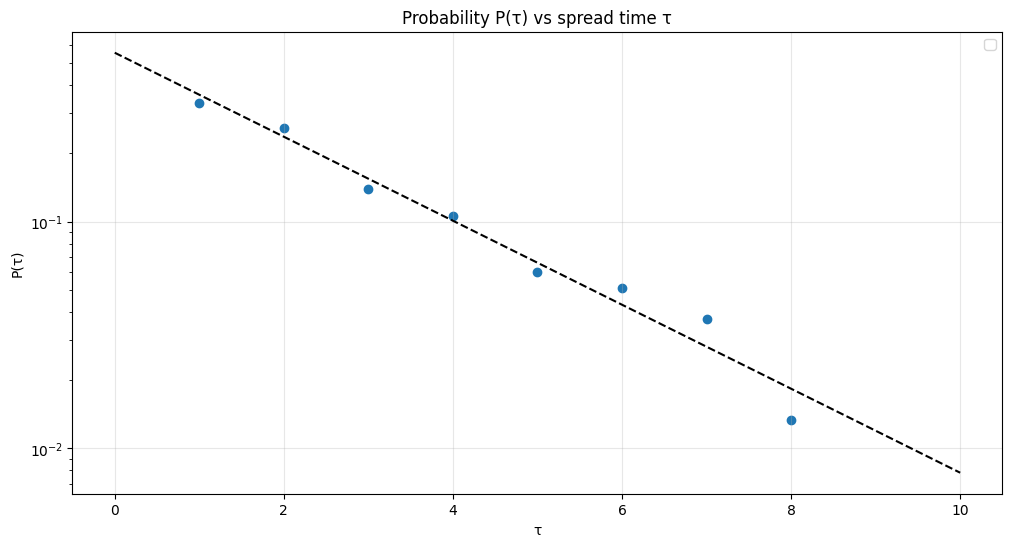

In [35]:
import matplotlib.pyplot as plt
import numpy as np
#Distribution of k
plt.figure(figsize=(12, 6))
apl_data_by_k = load_graphs(f"fig_data/fig06/fig06_g08.pkl")
spread_time_count = defaultdict(int)
for k in apl_data_by_k: 
    for st in apl_data_by_k[k]["spread_time"]:
        spread_time_count[st] += 1


spread_times = sorted(spread_time_count.keys())
counts = [spread_time_count[st] for st in spread_times]
normalized_counts = [c / sum(counts) for c in counts]
plt.scatter(spread_times, normalized_counts)

a,b = np.polyfit(spread_times, np.log(normalized_counts), 1)
x_line = np.array([0] + spread_times + [10])
y_line = np.exp(a * x_line + b)
plt.plot(x_line, y_line, "k--", color='black')
del apl_data_by_k, spread_time_count

print("Fig 6a")
print(f"A: a={a}, b={b}")
plt.yscale("log")
plt.xlabel("τ")
plt.ylabel("P(τ)")
plt.title("Probability P(τ) vs spread time τ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 6b
A: a=-1.2233951190645185, b=2.2975737364108304


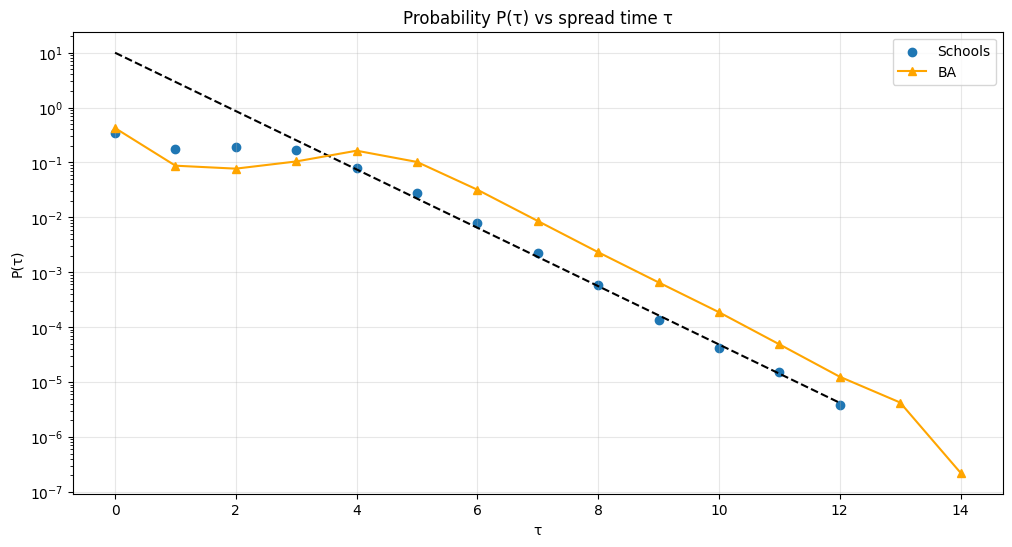

In [ ]:
plt.figure(figsize=(12, 6))
real_data_by_k = load_graphs(f"fig_data/fig05/fig05.pkl")
spread_time_count = defaultdict(int)
for k in real_data_by_k: 
    for st in real_data_by_k[k]["spread_time"]:
        spread_time_count[st] += 1


spread_times = sorted(spread_time_count.keys())
counts = [spread_time_count[st] for st in spread_times]
normalized_counts = [c / sum(counts) for c in counts]
plt.scatter(spread_times, normalized_counts, label="Schools")

a,b = np.polyfit(spread_times[3:], np.log(normalized_counts[3:]), 1)
x_line = np.array(spread_times)
y_line = np.exp(a * x_line + b)
plt.plot(x_line, y_line, "k--")
del real_data_by_k, spread_time_count

#BA
BA_data_by_k = load_graphs(f"fig_data/fig06/fig06_m09_N01k.pkl")
spread_time_count = defaultdict(int)
for k in BA_data_by_k: 
    for st in BA_data_by_k[k]["spread_time"]:
        spread_time_count[st] += 1


spread_times = sorted(spread_time_count.keys())
counts = [spread_time_count[st] for st in spread_times]
normalized_counts = [c / sum(counts) for c in counts]
plt.plot(spread_times, normalized_counts, color = "orange", label="BA", marker='^')
del BA_data_by_k, spread_time_count

print("Fig 6b")
print(f"A: a={a}, b={b}")
plt.yscale("log")
plt.xlabel("τ")
plt.ylabel("P(τ)")
plt.title("Probability P(τ) vs spread time τ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 6c


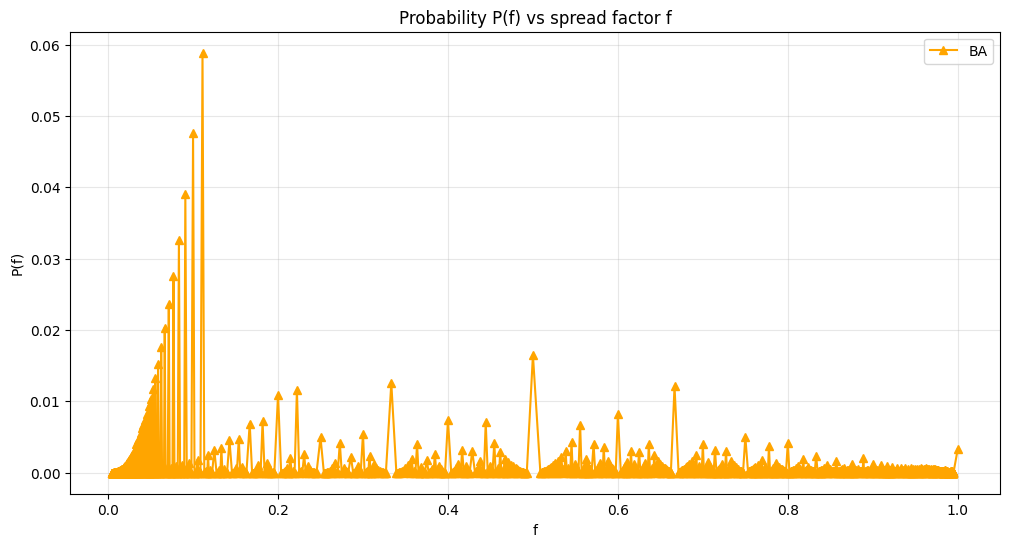

In [38]:
plt.figure(figsize=(12, 6))
#BA
BA_data_by_k = load_graphs(f"fig_data/fig06/fig06_m09_N01k.pkl")
spread_factor_count = defaultdict(int)
for k in BA_data_by_k: 
    for sf in BA_data_by_k[k]["spread_factor"]:
        spread_factor_count[sf] += 1


spread_factors = sorted(spread_factor_count.keys())
counts = [spread_factor_count[sf] for sf in spread_factors]
normalized_counts = [c / sum(counts) for c in counts]
plt.plot(spread_factors, normalized_counts, color = "orange", label="BA", marker='^')
del BA_data_by_k, spread_factor_count

print("Fig 6c")
plt.xlabel("f")
plt.ylabel("P(f)")
plt.title("Probability P(f) vs spread factor f")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 6c inset


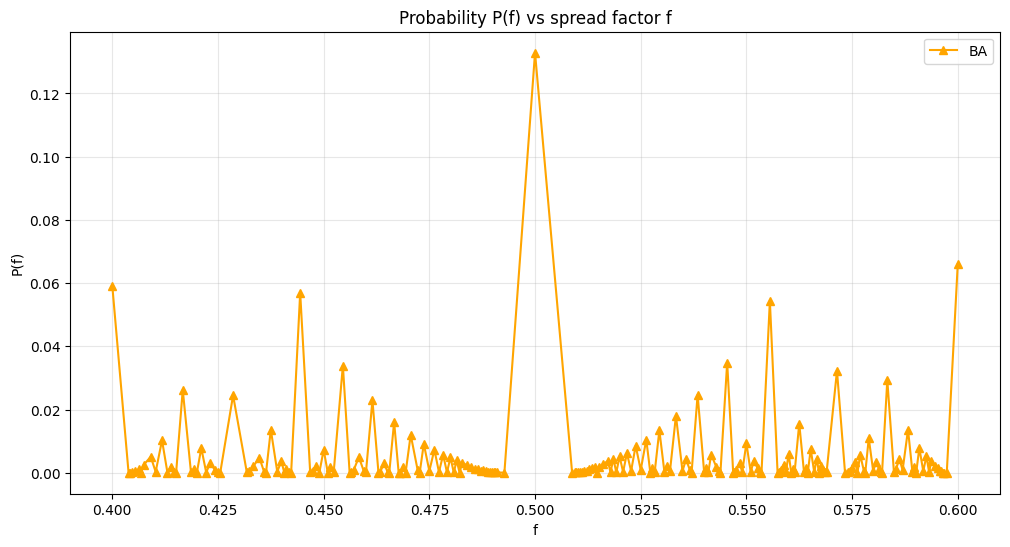

In [39]:
plt.figure(figsize=(12, 6))
#BA
BA_data_by_k = load_graphs(f"fig_data/fig06/fig06_m09_N01k.pkl")
spread_factor_count = defaultdict(int)
for k in BA_data_by_k: 
    for sf in BA_data_by_k[k]["spread_factor"]:
        if 0.4 <= sf <= 0.6:
            spread_factor_count[sf] += 1

spread_factors = sorted(spread_factor_count.keys())
counts = [spread_factor_count[sf] for sf in spread_factors]
normalized_counts = [c / sum(counts) for c in counts]
plt.plot(spread_factors, normalized_counts, color = "orange", label="BA", marker='^')
del BA_data_by_k, spread_factor_count

print("Fig 6c inset")
plt.xlabel("f")
plt.ylabel("P(f)")
plt.title("Probability P(f) vs spread factor f")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 6d


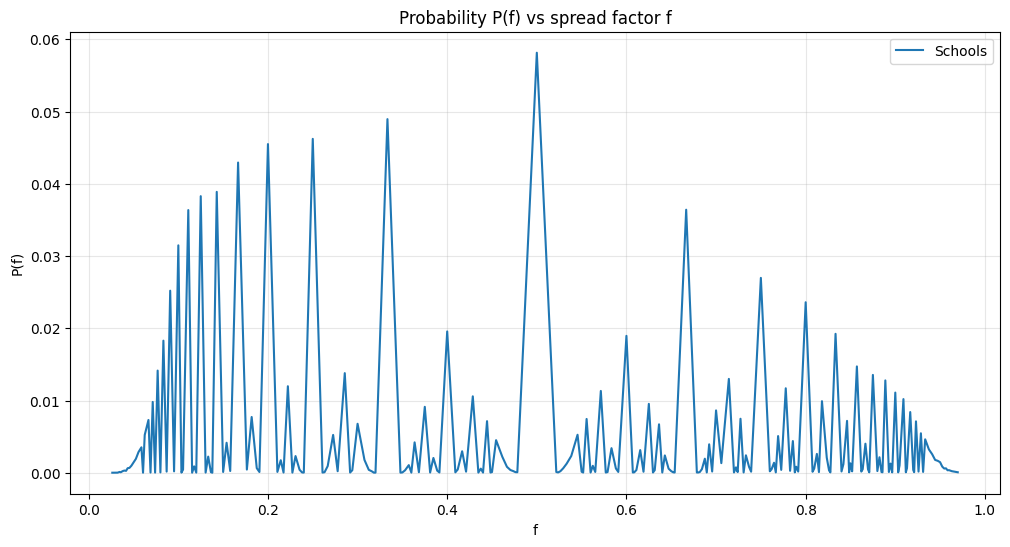

In [60]:
plt.figure(figsize=(12, 6))
real_data_by_k = load_graphs(f"fig_data/fig05/fig05.pkl")
spread_factor_count = defaultdict(int)
for k in real_data_by_k: 
    for sf in real_data_by_k[k]["spread_factor"]:
        if sf<1:
            spread_factor_count[sf] += 1

spread_factors = sorted(spread_factor_count.keys())
counts = [spread_factor_count[sf] for sf in spread_factors]
normalized_counts = [c / sum(counts) for c in counts]
plt.plot(spread_factors, normalized_counts, label="Schools")
del real_data_by_k, #spread_factor_count

print("Fig 6d")
plt.xlabel("f")
plt.ylabel("P(f)")
plt.title("Probability P(f) vs spread factor f")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 6e


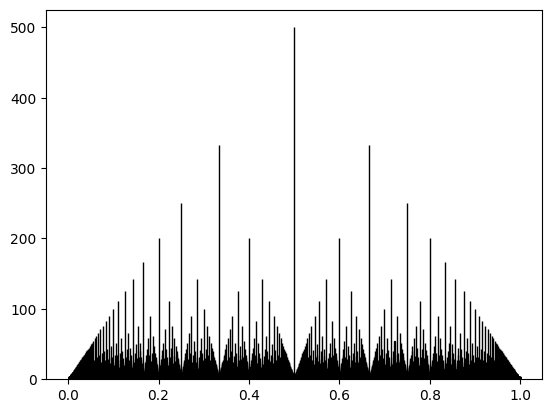

In [69]:
values = []
print("Fig 6e")
for k in range(1,1001):
    for n in range(1,k):
        values.append(n/k)

plt.hist(values, bins=len(set(values)), edgecolor='black')
plt.show()